In [ ]:
from google.colab import drive
drive.mount('/content/drivdri)

Mounted at /content/drive


In [ ]:
!pip install folium
!pip install contextily

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import contextily as ctx
import geopandas as gpd
from sklearn.decomposition import PCA
from folium import plugins
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely import wkt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import plotly.express as px

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PRAKTIKUM ML/Praktikum11/Data/earthquake_1995-2023.csv')

print("Preview Data Awal:")
display(df.head())

Preview Data Awal:


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

In [ ]:
df.isnull().sum()

,0
title,0
magnitude,0
date_time,0
cdi,0
mmi,0
alert,551
tsunami,0
sig,0
net,0
nst,0


In [ ]:
features = ['latitude', 'longitude', 'magnitude', 'depth']
df_clean = df[features].dropna().drop_duplicates()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print("\nData setelah scaling (5 baris pertama):\n", X_scaled[:5])


Data setelah scaling (5 baris pertama):
 [[-0.68151525  0.98383352 -1.00628237  0.90369567]
 [ 0.32361788 -1.19575185 -1.00628237 -0.03793899]
 [-1.5968222  -1.04417567 -0.77801329  0.73876365]
 [ 1.88882337 -1.81536628  0.59160117 -0.32186291]
 [ 1.89279941 -1.81619445  0.81987025 -0.41028157]]


In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X_scaled)

df_pca_db = pd.DataFrame(reduced, columns=["PCA 1", "PCA 2"])

df_pca_db["Location"] = df.loc[df_clean.index, "title"]
df_pca_db["Magnitude"] = df.loc[df_clean.index, "magnitude"]

print("\nDataframe PCA:\n", df_pca_db.head())


Dataframe PCA:
       PCA 1     PCA 2                                  Location  Magnitude
0  0.518173 -1.638837          M 6.5 - 42 km W of Sola, Vanuatu        6.5
1 -0.068808 -0.219725  M 6.5 - 43 km S of Intipucá, El Salvador        6.5
2  1.686083 -0.778529  M 6.6 - 25 km ESE of Loncopué, Argentina        6.6
3 -0.736488  1.865274     M 7.2 - 98 km S of Sand Point, Alaska        7.2
4 -0.749507  2.074952                  M 7.3 - Alaska Peninsula        7.3


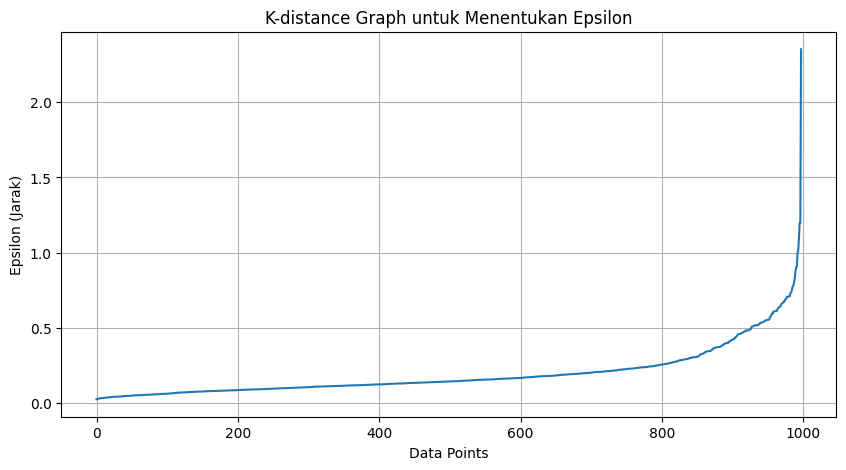

In [ ]:
min_samples = 2 * X_scaled.shape[1]
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_pca_db[['PCA 1', 'PCA 2']])
distances, indices = neighbors_fit.kneighbors(df_pca_db[['PCA 1', 'PCA 2']])

distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph untuk Menentukan Epsilon')
plt.xlabel('Data Points')
plt.ylabel('Epsilon (Jarak)')
plt.grid(True)
plt.show()

In [ ]:
eps_value = 0.3
min_samples_value = 8

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)

clusters = dbscan.fit_predict(df_pca_db[['PCA 1', 'PCA 2']])

df_pca_db["Klasifikasi_DBSCAN"] = clusters

print("\nJumlah titik per cluster:\n", df_pca_db["Klasifikasi_DBSCAN"].value_counts())


Jumlah titik per cluster:
 Klasifikasi_DBSCAN
 0    872
-1    114
 1      8
 2      4
Name: count, dtype: int64


In [ ]:
if len(set(clusters)) > 1:
    score = silhouette_score(df_pca_db[['PCA 1', 'PCA 2']], clusters)
    print(f"\nSilhouette Score: {score:.4f}")
else:
    print("\nHanya satu cluster atau semua noise, atur ulang parameter eps.")


Silhouette Score: 0.2552


In [ ]:
df_pca_db["Klasifikasi_DBSCAN"] = df_pca_db["Klasifikasi_DBSCAN"].astype(str)

fig = px.scatter(
    df_pca_db,
    x="PCA 1",
    y="PCA 2",
    color="Klasifikasi_DBSCAN",
    hover_name="Location",
    hover_data=["Magnitude"],
    title=f"Persebaran Data Gempa Berdasarkan Klasifikasi DBSCAN (eps={eps_value})",
    width=1000,
    height=600
)

fig.show()

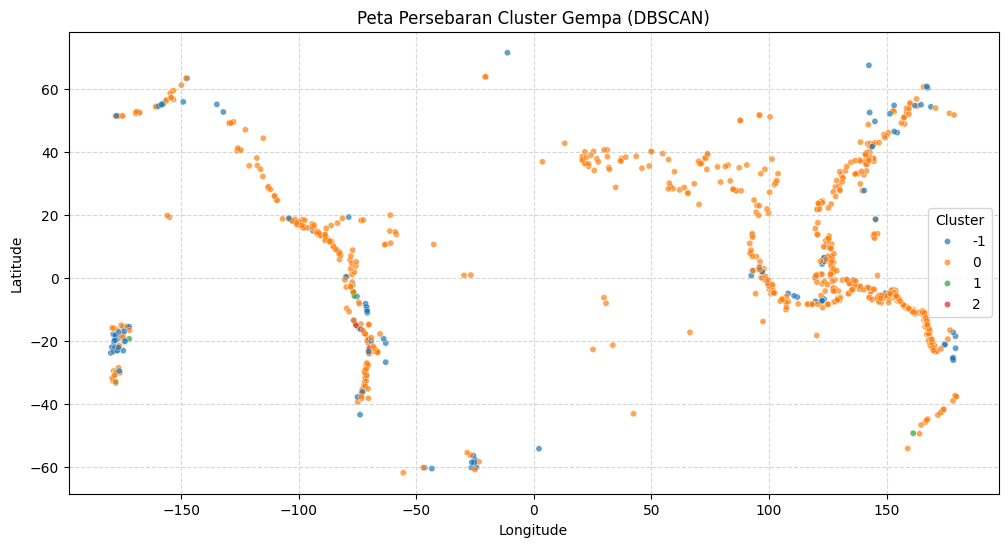

In [ ]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df_clean,
    x='longitude',
    y='latitude',
    hue=clusters,
    palette='tab10',
    s=20,
    alpha=0.7
)
plt.title('Peta Persebaran Cluster Gempa (DBSCAN)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()